In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

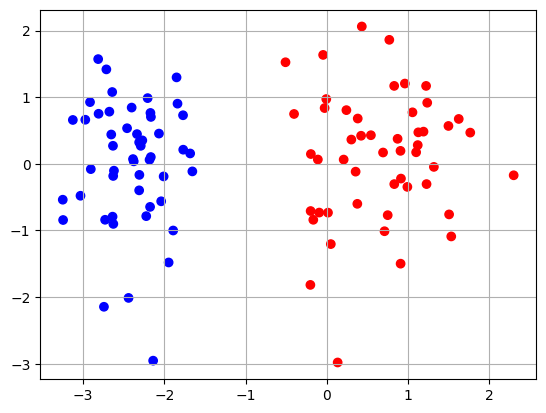

In [2]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100, n_features=2, n_redundant=0, n_informative=1,
                           n_classes=2, n_clusters_per_class=1, weights=[0.5, 0.5], class_sep=15.0, random_state=41, hypercube=False)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
plt.grid()
plt.show()

In [3]:
df = pd.DataFrame(np.column_stack([X[:, 0], X[:, 1], y]), columns=['Feature 1', 'Feature 2', 'Target'])
df.head()

,Feature 1,Feature 2,Target
0,0.355239,-0.116976,1.0
1,-0.092828,-0.731152,1.0
2,-0.198498,-0.708106,1.0
3,-2.440011,-2.011992,0.0
4,-0.044848,1.634932,1.0


In [4]:
# Perceptron with Stochastic Gradient Descent (SGD)
class Perceptron():
    def __init__(self, lr, epochs):
        self.lr = lr
        self.N = epochs
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n, m = X.shape
        self.weights = np.ones(m) # (m,)
        self.bias = 0.0

        for _ in tqdm(range(self.N), desc="Training"):
            random_indices = np.random.permutation(n)
            for idx in random_indices:
                xi = X[idx] # (m,)
                yi = y[idx] # ()
                y_hat = np.dot(xi, self.weights) + self.bias
                if yi * y_hat <= 0:
                    self.weights -= self.lr * (-yi) * xi
                    self.bias -= self.lr * (-yi)
        return self.bias, self.weights

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        y_pred = np.sign(z)
        return y_pred

In [6]:
clf = Perceptron(lr=1e-2, epochs=100)
b, [w1, w2] = clf.fit(X, y)
print(f"Bias: {b}, Weights: {w1}, {w2}")

Training: 100%|██████████| 100/100 [00:00<00:00, 2787.47it/s]

Bias: 0.5700000000000003, Weights: 0.9896675481882103, 0.18474595409667366


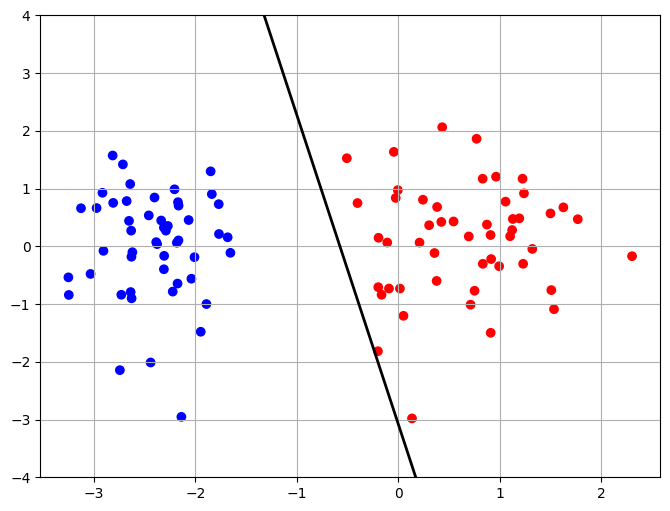

In [7]:
x_plot = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_plot = (-w1/w2) * x_plot - b/w2
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
plt.plot(x_plot, y_plot, color='black', linewidth=2)
plt.ylim(-4, 4)
plt.grid()
plt.show()